In [118]:
URL = "https://data.seattle.gov/api/views/65db-xm6k/rows.csv?accessType=DOWNLOAD"

import pandas as pd
import matplotlib.pyplot as plt

local_file = "data/fremont.csv"

data = pd.read_csv(local_file)
print(data.shape)
data.head()


(175200, 4)


,Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
0,08/01/2022 12:00:00 AM,23.0,7.0,16.0
1,08/01/2022 01:00:00 AM,12.0,5.0,7.0
2,08/01/2022 02:00:00 AM,3.0,0.0,3.0
3,08/01/2022 03:00:00 AM,5.0,2.0,3.0
4,08/01/2022 04:00:00 AM,10.0,2.0,8.0


In [119]:
from pathlib import Path

if Path(local_file).exists():
    print(f"le fichier {local_file} est déjà là")
else:
    print(f"allons chercher le fichier {local_file}")

    import requests
    req = requests.get(URL)
    print(req.status_code)

    with open(local_file, 'w') as writer:
        writer.write(req.text)

!head $local_file

le fichier data/fremont.csv est déjà là
Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
08/01/2022 12:00:00 AM,23,7,16
08/01/2022 01:00:00 AM,12,5,7
08/01/2022 02:00:00 AM,3,0,3
08/01/2022 03:00:00 AM,5,2,3
08/01/2022 04:00:00 AM,10,2,8
08/01/2022 05:00:00 AM,27,5,22
08/01/2022 06:00:00 AM,100,43,57
08/01/2022 07:00:00 AM,219,90,129
08/01/2022 08:00:00 AM,335,143,192


In [120]:
!grep '01/01/2014 12:00:00 AM' $local_file

01/01/2014 12:00:00 AM,23,5,18
01/01/2014 12:00:00 AM,23,5,18


In [121]:
i,_ = data.shape
data.drop_duplicates(['Date', 'Fremont Bridge Total','Fremont Bridge East Sidewalk','Fremont Bridge West Sidewalk'], inplace=True)
data.shape

(87600, 4)

## échauffement : le DatetimeIndex

In [122]:
sample_dates = pd.to_datetime([
    "2024-01-15 08:00:00",
    "2024-01-20 17:30:00",
    "2024-02-03 12:00:00",
])

In [123]:
# Question 1

type(sample_dates)
# type : pandas.DatetimeIndex

pandas.DatetimeIndex

In [124]:
# Question 2

print(sample_dates.date)
# retourne le tableau des dates (sans les heures)
print(sample_dates.time)
# retourne le tableau des heures
sample_dates.dayofweek
# retourne le numéro du jour de la semaine (ici : lundi,samedi,samedi)


[datetime.date(2024, 1, 15) datetime.date(2024, 1, 20)
 datetime.date(2024, 2, 3)]
[datetime.time(8, 0) datetime.time(17, 30) datetime.time(12, 0)]


Index([0, 5, 5], dtype='int32')

In [125]:
# Question 3

sample_dates[(sample_dates >= "2024-01-20")]

DatetimeIndex(['2024-01-20 17:30:00', '2024-02-03 12:00:00'], dtype='datetime64[us]', freq=None)

In [126]:
# Question 4

sample_dates[(sample_dates.month == 1) & (sample_dates.year == 2024)]

DatetimeIndex(['2024-01-15 08:00:00', '2024-01-20 17:30:00'], dtype='datetime64[us]', freq=None)

## parser les dates

In [127]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 87600 entries, 0 to 87599
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          87600 non-null  str    
 1   Fremont Bridge Total          87586 non-null  float64
 2   Fremont Bridge East Sidewalk  87586 non-null  float64
 3   Fremont Bridge West Sidewalk  87586 non-null  float64
dtypes: float64(3), str(1)
memory usage: 4.5 MB


In [128]:
data.dtypes

Date                                str
Fremont Bridge Total            float64
Fremont Bridge East Sidewalk    float64
Fremont Bridge West Sidewalk    float64
dtype: object

In [129]:
data.index = pd.to_datetime(data['Date'], format="%m/%d/%Y %I:%M:%S %p")
data.drop('Date', axis=1, inplace=True)


## renommons les colonnes

In [130]:
data.columns = ['Total', 'West', 'East']


## données manquantes et extension types

In [131]:
# Question 1

data[~data.isna().any(axis=1)]

,Total,West,East
Date,,,
2022-08-01 00:00:00,23.0,7.0,16.0
2022-08-01 01:00:00,12.0,5.0,7.0
2022-08-01 02:00:00,3.0,0.0,3.0
2022-08-01 03:00:00,5.0,2.0,3.0
2022-08-01 04:00:00,10.0,2.0,8.0
...,...,...,...
2022-09-30 19:00:00,168.0,57.0,111.0
2022-09-30 20:00:00,73.0,33.0,40.0
2022-09-30 21:00:00,69.0,30.0,39.0


In [132]:
# Question 2

data.convert_dtypes(convert_floating = False)

,Total,West,East
Date,,,
2022-08-01 00:00:00,23,7,16
2022-08-01 01:00:00,12,5,7
2022-08-01 02:00:00,3,0,3
2022-08-01 03:00:00,5,2,3
2022-08-01 04:00:00,10,2,8
...,...,...,...
2022-09-30 19:00:00,168,57,111
2022-09-30 20:00:00,73,33,40
2022-09-30 21:00:00,69,30,39


## à quoi ça ressemble

<Axes: xlabel='Date'>

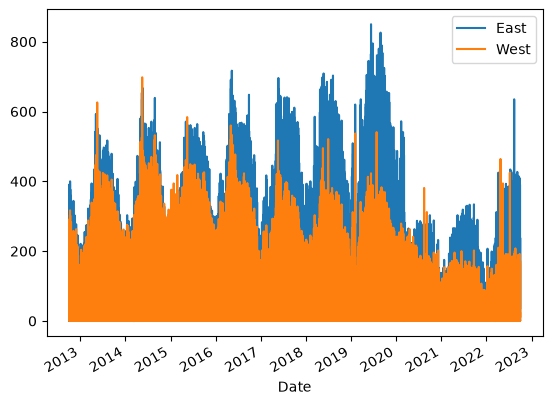

In [133]:
data[['East', 'West']].plot()

## resample() : changer la fréquence temporelle

<Axes: xlabel='Date'>

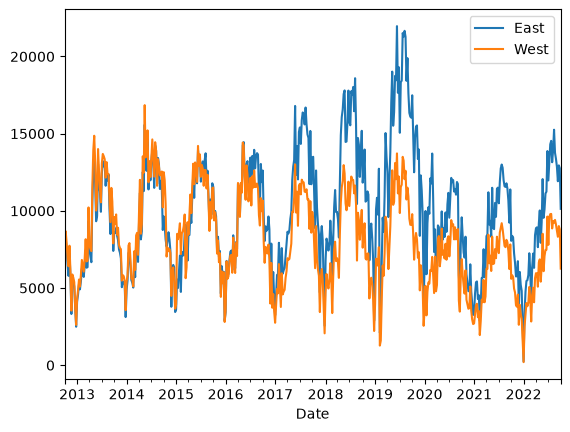

In [134]:
# Question 1

(data.resample('1W').sum())[['East', 'West']].plot()

In [135]:
# Question 2 : vérification

print(data.shape[0] >= 7*24*data.resample("1W").sum().shape[0])

False


## découpage temporel

In [ ]:
data = data[(data.index < "2018-01-01")]
data

# comment ferait-on pour couper au 12 février 2017 à 14h32:30 ?
# data[(data.index <= "2017-02-12 14:32:30")]

,Total,West,East
Date,,,
2012-10-03 00:00:00,13.0,4.0,9.0
2012-10-03 01:00:00,10.0,4.0,6.0
2012-10-03 02:00:00,2.0,1.0,1.0
2012-10-03 03:00:00,5.0,2.0,3.0
2012-10-03 04:00:00,7.0,6.0,1.0
...,...,...,...
2017-12-31 19:00:00,21.0,9.0,12.0
2017-12-31 20:00:00,14.0,6.0,8.0
2017-12-31 21:00:00,13.0,3.0,10.0


## évolution annuelle

(0.0, 1059839.95)

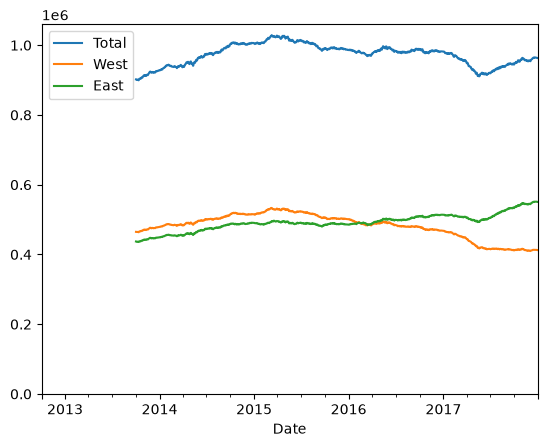

In [142]:
data.resample('1D').sum().rolling(365).sum().plot().set_ylim(bottom=0)


## profil journalier moyen